# Tutorial 02: Smarter Training

In Tutorial 01, we trained on clean data and stopped after a fixed number of iterations. In practice, training data is noisy, and stopping too early or too late both hurt generalization.

This tutorial introduces **validation-guided training**:

1. **Prepare data** — add noise; split into train and validation sets
2. **The overfitting problem** — see what happens without validation
3. **Add validation** — track val/mse alongside train/mse
4. **Enable early stopping** — let the trainer stop automatically
5. **Read history** — compare `best()` vs `latest()` to understand what was saved

### Step 0: Setups
---

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from utils import add_necessary_paths, check_torch
add_necessary_paths()

import utils.u02 as u
import talos as ta
import numpy as np

check_torch()
ta.set_seed()

:: PyTorch version: 2.6.0+cu124
:: CUDA is available. Number of CUDA devices: 7


DeferredCudaCallError: CUDA call failed lazily at initialization with error: device >= 0 && device < num_gpus INTERNAL ASSERT FAILED at "/pytorch/aten/src/ATen/cuda/CUDAContext.cpp":49, please report a bug to PyTorch. device=6, num_gpus=

CUDA call was originally invoked at:

  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/sbh/miniconda3/envs/talos/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/sbh/miniconda3/envs/talos/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/sbh/miniconda3/envs/talos/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/home/sbh/miniconda3/envs/talos/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/home/sbh/miniconda3/env

### Step 1: Prepare data
---

We use the same $\sin(x)$ task, but now add Gaussian noise to $y$ to simulate real-world measurement error. We also keep an explicit validation set to monitor generalization during training.

In [5]:
# Generate noisy sin(x) data (noise std = 0.15)
X, Y = u.generate_data(n=200, noise=0.15, seed=0)
dataset = ta.Dataset(X, Y, name='noisy sin(x)')
dataset.report()

:: Dataset `noisy sin(x)` (size: 200)
   - X: type=<class 'numpy.ndarray'>, shape=(200, 1)
   - Y: type=<class 'numpy.ndarray'>, shape=(200, 1)


In [6]:
# Split: 80% train, 20% validation
train_set, val_set = dataset.split(4, 1, shuffle=True)
train_set.report()
val_set.report()

:: Dataset `noisy sin(x) (1/2)` (size: 160)
   - X: type=<class 'numpy.ndarray'>, shape=(160, 1)
   - Y: type=<class 'numpy.ndarray'>, shape=(160, 1)
:: Dataset `noisy sin(x) (2/2)` (size: 40)
   - X: type=<class 'numpy.ndarray'>, shape=(40, 1)
   - Y: type=<class 'numpy.ndarray'>, shape=(40, 1)


### Step 2: The overfitting problem
---

Let's first train without a validation set. The trainer only sees train/mse — it has no way to know when the model starts memorizing noise instead of learning the underlying pattern.

In [21]:
# Train without validation — runs for the full 5000 iterations
model_a = ta.model.torch_zoo.MLP(1, [32, 32], 1, activation='tanh')
trainer_a = u.get_trainer(model_a, lr=1e-3, print_every=1000)
trainer_a.train(train_set, max_iterations=20000)

!! save_best=True has no effect without a validation set
>> Training started (max_iterations=20000)
>> Iter 1000 | train/mse = 0.0192203
>> Iter 2000 | train/mse = 0.0185219
>> Iter 3000 | train/mse = 0.0180104
>> Iter 4000 | train/mse = 0.0177263
>> Iter 5000 | train/mse = 0.0176414
>> Iter 6000 | train/mse = 0.0175537
>> Iter 7000 | train/mse = 0.0174327
>> Iter 8000 | train/mse = 0.0172831
>> Iter 9000 | train/mse = 0.0171725
>> Iter 10000 | train/mse = 0.0171733
>> Iter 11000 | train/mse = 0.0170418
>> Iter 12000 | train/mse = 0.0170377
>> Iter 13000 | train/mse = 0.017154
>> Iter 14000 | train/mse = 0.0170025
>> Iter 15000 | train/mse = 0.0169964
>> Iter 16000 | train/mse = 0.0172758
>> Iter 17000 | train/mse = 0.0169401
>> Iter 18000 | train/mse = 0.0168879
>> Iter 19000 | train/mse = 0.0168537
>> Iter 20000 | train/mse = 0.0168456
>> Training complete (iter 20000)


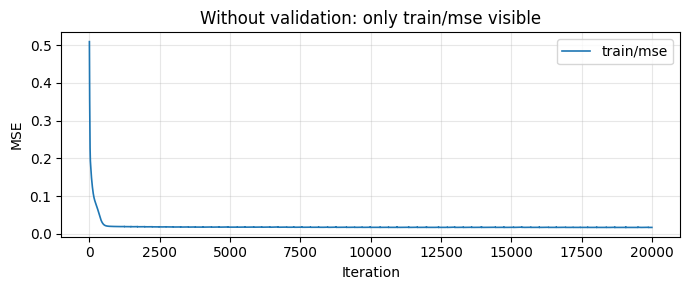

In [22]:
# Training loss is tracked — but we have no signal about generalization
u.plot_loss_curves(trainer_a.history,
                   keys=['train/mse'],
                   labels=['train/mse'],
                   title='Without validation: only train/mse visible')

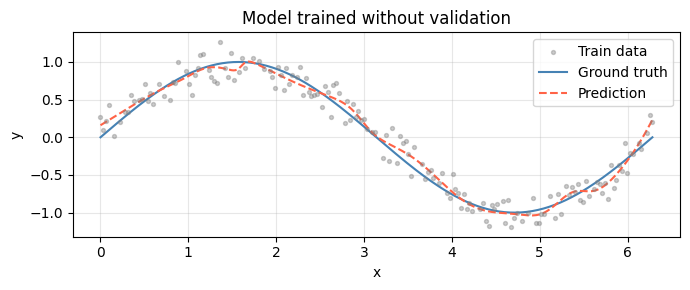

In [23]:
# Visualize predictions — the model may have overfit to noise
import math
X_dense = np.linspace(0, 2 * math.pi, 300).reshape(-1, 1)
Y_true   = np.sin(X_dense)
Y_pred_a = model_a.predict(ta.Dataset(X_dense, Y_true))

u.plot_predictions(X_dense, Y_true, Y_pred_a,
                   train_X=train_set.X, train_Y=train_set.Y,
                   title='Model trained without validation')

### Step 3: Add validation
---

Pass `val_set` to `trainer.train()` and the trainer will compute `val/mse` at regular intervals. Now you can see both train and val loss — the gap between them reveals how well the model generalizes.

In [10]:
# Fresh model — train with explicit validation set
model_b = ta.model.torch_zoo.MLP(1, [32, 32], 1, activation='tanh')
trainer_b = u.get_trainer(model_b, lr=1e-3, print_every=1000)
trainer_b.config.validate_every = 200

trainer_b.train(train_set, val_set=val_set, val_metrics=['mse'],
                max_iterations=5000)

>> Training started (max_iterations=5000)
.. val/mse = 0.0697103
.. [Best] val/mse = 0.0697103 (iter 200)
.. val/mse = 0.0395891
.. [Best] val/mse = 0.0395891 (iter 400)
.. val/mse = 0.0280274
.. [Best] val/mse = 0.0280274 (iter 600)
.. val/mse = 0.0274559
.. [Best] val/mse = 0.0274559 (iter 800)
>> Iter 1000 | train/mse = 0.0194439
.. val/mse = 0.0283601
.. val/mse = 0.028892
.. val/mse = 0.0291183
.. val/mse = 0.0292181
.. val/mse = 0.0292666
>> Iter 2000 | train/mse = 0.0188862
.. val/mse = 0.02928
.. val/mse = 0.0293139
.. val/mse = 0.0293207
.. val/mse = 0.0293259
.. val/mse = 0.0292875
>> Iter 3000 | train/mse = 0.018758
.. val/mse = 0.0293088
.. val/mse = 0.0292944
.. val/mse = 0.0297175
.. val/mse = 0.0292566
.. val/mse = 0.0292313
>> Iter 4000 | train/mse = 0.0186671
.. val/mse = 0.0291944
.. val/mse = 0.0293348
.. val/mse = 0.0291436
.. val/mse = 0.0291071
.. val/mse = 0.0290888
>> Iter 5000 | train/mse = 0.0185685
.. val/mse = 0.0290407
>> Restored best model (iter 800, val/

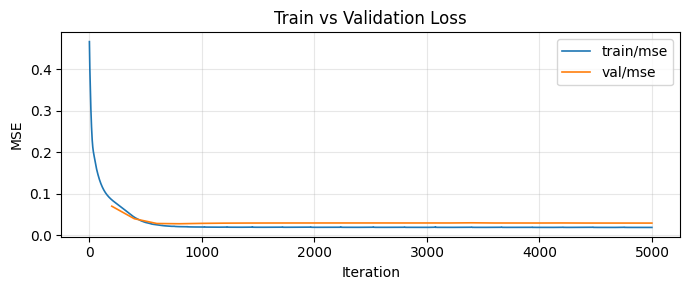

In [11]:
# Compare train vs val loss
u.plot_loss_curves(trainer_b.history,
                   keys=['train/mse', 'val/mse'],
                   labels=['train/mse', 'val/mse'],
                   title='Train vs Validation Loss')

### Step 4: Enable early stopping
---

Monitoring val/mse manually is tedious. `early_stop=True` automates this: training halts when val/mse hasn't improved for `patience` consecutive validations. `save_best=True` (on by default) additionally restores the best checkpoint at the end.

In [12]:
# Fresh model — enable early stopping
model_c = ta.model.torch_zoo.MLP(1, [32, 32], 1, activation='tanh')
trainer_c = u.get_trainer(model_c, lr=1e-3, print_every=500)
trainer_c.config.validate_every = 200
trainer_c.config.early_stop     = True
trainer_c.config.patience        = 10   # stop after 10 non-improving validations

trainer_c.train(train_set, val_set=val_set, val_metrics=['mse'],
                max_iterations=10000)

>> Training started (max_iterations=10000)
.. val/mse = 0.0832636
.. [Best] val/mse = 0.0832636 (iter 200)
.. val/mse = 0.0640122
.. [Best] val/mse = 0.0640122 (iter 400)
>> Iter 500 | train/mse = 0.0707295
.. val/mse = 0.0510758
.. [Best] val/mse = 0.0510758 (iter 600)
.. val/mse = 0.0352058
.. [Best] val/mse = 0.0352058 (iter 800)
>> Iter 1000 | train/mse = 0.0240177
.. val/mse = 0.0294274
.. [Best] val/mse = 0.0294274 (iter 1000)
.. val/mse = 0.0306211
.. val/mse = 0.030961
>> Iter 1500 | train/mse = 0.0195741
.. val/mse = 0.0308877
.. val/mse = 0.0307579
>> Iter 2000 | train/mse = 0.0192342
.. val/mse = 0.0306406
.. val/mse = 0.0305444
.. val/mse = 0.0304604
>> Iter 2500 | train/mse = 0.0190764
.. val/mse = 0.0303734
.. val/mse = 0.0302315
>> Iter 3000 | train/mse = 0.0189727
.. val/mse = 0.0302464
>> Restored best model (iter 1000, val/mse = 0.0294274)
>> Early stopping at iter 3000 (patience=10)


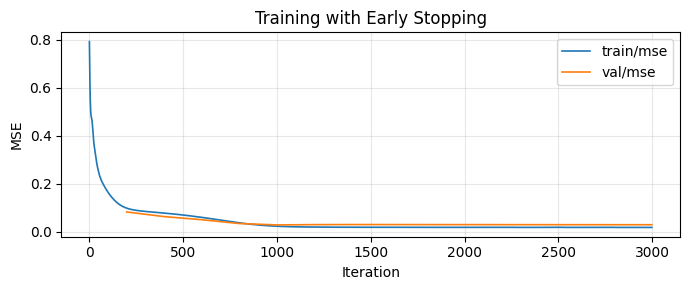

In [13]:
# Observe the early stop: iterations used << max_iterations
u.plot_loss_curves(trainer_c.history,
                   keys=['train/mse', 'val/mse'],
                   labels=['train/mse', 'val/mse'],
                   title='Training with Early Stopping')

### Step 5: Read history — best() vs latest()
---

After training with `save_best=True`, the model weights reflect the **best** checkpoint, not the last iteration. `history.best()` shows you exactly which iteration that was and what score it achieved — which is what matters for deployment.

In [14]:
# latest() — where training stopped
print('latest val/mse:', trainer_c.history.latest('val/mse'))

latest val/mse: 0.030246365815401077


In [15]:
# best() — the checkpoint that was restored
best_iter, best_val = trainer_c.history.best('val/mse')
print(f'best val/mse:   {best_val:.6f}  (at iteration {best_iter + 1})')

best val/mse:   0.029427  (at iteration 1000)


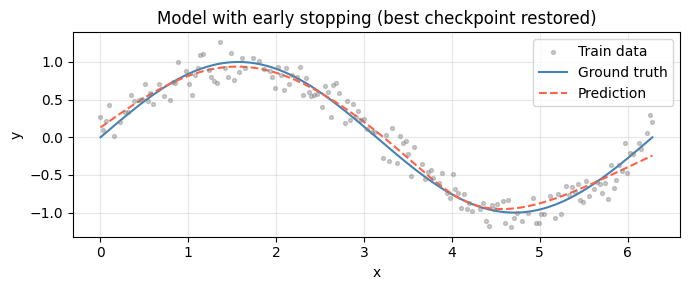

In [16]:
# Visualize the final model (restored to best checkpoint)
Y_pred_c = model_c.predict(ta.Dataset(X_dense, Y_true))

u.plot_predictions(X_dense, Y_true, Y_pred_c,
                   train_X=train_set.X, train_Y=train_set.Y,
                   title='Model with early stopping (best checkpoint restored)')

### Takeaway

Three config knobs completely change training behavior:

```python
trainer.config.early_stop    = True
trainer.config.patience       = 10
trainer.config.validate_every = 200
```

- **Validation** gives you a generalization signal at no extra coding cost
- **Early stopping** saves compute and automatically prevents overfit
- **`save_best=True`** (default) ensures the deployed model is the best one seen, not the last one

Use `history.best('val/mse')` to confirm the iteration and score of the restored checkpoint.

In the **next tutorial**, we'll automate hyperparameter selection so you don't have to tune `lr`, hidden size, or other knobs by hand.